2025-04-01 14:59:10: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-04-01 14:59:10: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-04-01 14:59:10: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-04-01 14:59:10: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-04-01 14:59:10: oggm.cfg: PARAMS['store_fl_diagnostics'] changed from `False` to `True`.
2025-04-01 14:59:39: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-04-01 14:59:39: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-04-01 14:59:39: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2025-04-01 14:59:40: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers


Processing GCM data...


2025-04-01 14:59:41: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:42: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:43: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:45: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:46: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:47: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:48: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:49: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:51: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-01 14:59:52: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1

Running GCM projections...


2025-04-01 14:59:59: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:00: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:00: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:01: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:01: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:02: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:03: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:03: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:04: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:04: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2025-04-01 15:00:05: oggm.workflow: Execute entity

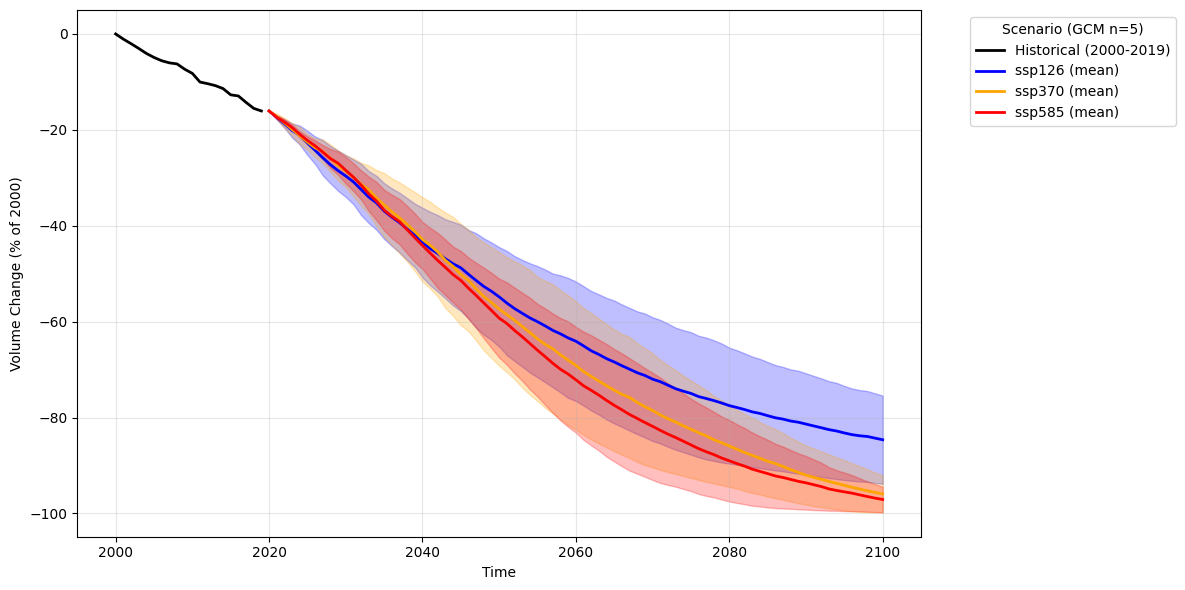

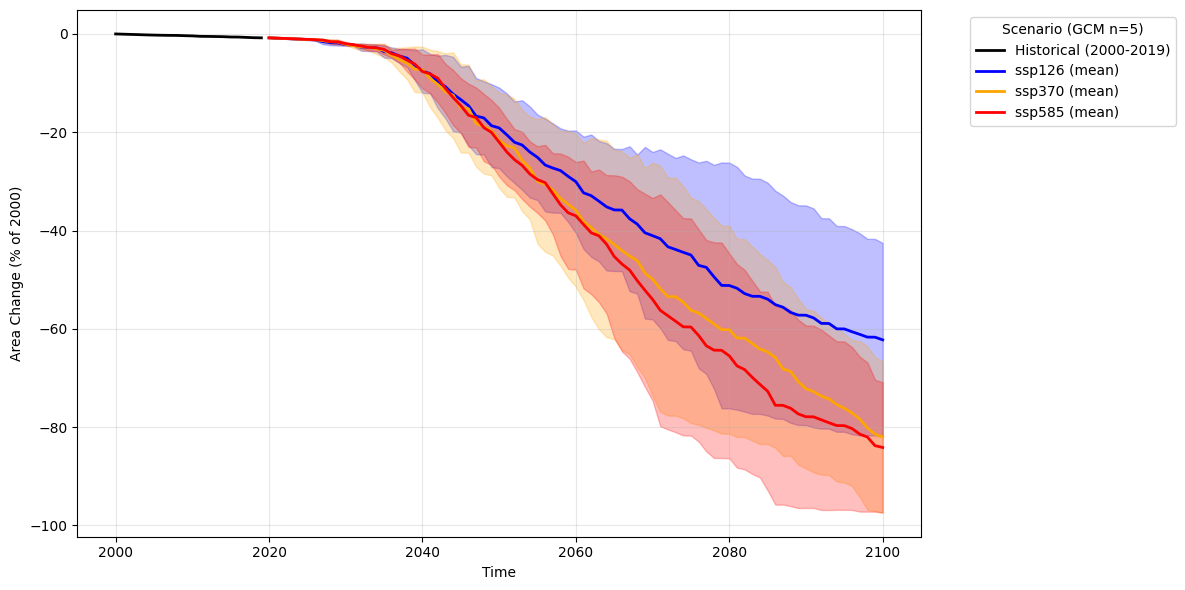

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import oggm.cfg as cfg
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.shop import gcm_climate
import pandas as pd
from matplotlib.colors import to_rgba  
import numpy as np

# Initializse OGGM and create directory.
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_gcm_run', reset=True)
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['store_fl_diagnostics'] = True

# Define RGI ID.
rgi_ids = ['RGI60-06.00291']  # Vestari Hagafellsjökull

# Get the pre-processed glacier directories
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup/'
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=base_url)

# Define the ISIMIP3b GCMs and SSP scenarios.
gcms = [
    'gfdl-esm4_r1i1p1f1',
    'mpi-esm1-2-hr_r1i1p1f1',
    'mri-esm2-0_r1i1p1f1',
    'ipsl-cm6a-lr_r1i1p1f1',
    'ukesm1-0-ll_r1i1p1f2'
]
scenarios = ['ssp126', 'ssp370', 'ssp585']

# Dynamic spinup for the hisorical period (geometry changes during simulation)

workflow.execute_entity_task(
    tasks.run_dynamic_spinup,
    gdirs,
    spinup_start_yr=2000,
    output_filesuffix='_dynamic_spinup',
    ye=2019,  # Stop at 2019 to stop overlap with GCM data (This starts at 2020)
    minimise_for='area',
    precision_percent=5,
    add_fixed_geometry_spinup=True
)

# Download and process GCM data
print("Processing GCM data...")
for gcm in gcms:
    for ssp in scenarios:
        workflow.execute_entity_task(
            gcm_climate.process_monthly_isimip_data,
            gdirs,
            ssp=ssp,
            member=gcm,
            output_filesuffix=f'_ISIMIP3b_{gcm}_{ssp}'
        )

# Run projections for each GCM and SSP scenario with continuous geometry
print("Running GCM projections...")
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        workflow.execute_entity_task(
            tasks.run_from_climate_data, 
            gdirs,
            climate_filename='gcm_data',
            climate_input_filesuffix=rid,
            init_model_filesuffix='_dynamic_spinup',  # Use the dynamic spinup state
            output_filesuffix=rid,
            ys=2020,
            ye=2100
        )

# Compile results for each GCM and SSP scenario and assign coordinates
results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        ds_proj = utils.compile_run_output(gdirs, input_filesuffix=rid)
        ds_proj = ds_proj.assign_coords(GCM=gcm, SCENARIO=ssp)
        results.append(ds_proj)

# Compile historical results to include in visualization
ds_hist = utils.compile_run_output(gdirs, input_filesuffix='_dynamic_spinup')

# Combine all results into a single dataset
ds_total = xr.concat(results, dim='run')

# Calculate statistics for volume and area
ds_total_volume = ds_total.volume.groupby('SCENARIO').sum(dim='rgi_id')
ds_total_area = ds_total.area.groupby('SCENARIO').sum(dim='rgi_id')

# Calculate reference values for 2000 (start of spinup) instead of 2020
volume_2000 = ds_hist.volume.sum(dim='rgi_id').isel(time=0)
area_2000 = ds_hist.area.sum(dim='rgi_id').isel(time=0)

# Calculate relative changes from 2000 (not 2020) for both historical and projection data
# First for historical data
ds_hist_volume_rel = -((volume_2000 - ds_hist.volume.sum(dim='rgi_id')) / volume_2000 * 100)
ds_hist_area_rel = -((area_2000 - ds_hist.area.sum(dim='rgi_id')) / area_2000 * 100)

# Then for projection data
ds_total_volume_rel = -((volume_2000 - ds_total_volume) / volume_2000 * 100)
ds_total_area_rel = -((area_2000 - ds_total_area) / area_2000 * 100)

# Calculate mean and standard deviation
for ds_name in ['ds_total_volume_rel', 'ds_total_area_rel']:
    ds = locals()[ds_name]
    globals()[f"{ds.name}_mean"] = ds.groupby('SCENARIO').mean(dim='run')
    globals()[f"{ds.name}_std"] = ds.groupby('SCENARIO').std(dim='run')

# Colour dictionary for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Plot volume changes with improved colors and historical data
fig1, ax1 = plt.subplots(figsize=(12, 6))

# Plot historical data first
ax1.plot(
    ds_hist_volume_rel.time,
    ds_hist_volume_rel,
    color='black',
    label='Historical (2000-2019)',
    lw=2
)

# Then plot projection scenarios
for scenario in color_dict.keys():
    # Plot mean volume change
    ax1.plot(
        volume_mean.time,
        volume_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region 
    ax1.fill_between(
        volume_mean.time,
        volume_mean.sel(SCENARIO=scenario) - volume_std.sel(SCENARIO=scenario),
        volume_mean.sel(SCENARIO=scenario) + volume_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25
    )

ax1.set_xlabel('Time')
ax1.set_ylabel('Volume Change (% of 2000)')
ax1.grid(True, alpha=0.3)
ax1.set_title('')
ax1.legend(title='Scenario (GCM n=5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Volume_Changes_from_2000.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot area changes with historical data
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Plot historical data first
ax2.plot(
    ds_hist_area_rel.time,
    ds_hist_area_rel,
    color='black',
    label='Historical (2000-2019)',
    lw=2
)

# Then plot projection scenarios
for scenario in color_dict.keys():
    # Plot mean area change
    ax2.plot(
        area_mean.time,
        area_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region
    ax2.fill_between(
        area_mean.time,
        area_mean.sel(SCENARIO=scenario) - area_std.sel(SCENARIO=scenario),
        area_mean.sel(SCENARIO=scenario) + area_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25
    )

ax2.set_xlabel('Time')
ax2.set_ylabel('Area Change (% of 2000)')
ax2.grid(True, alpha=0.3)
ax2.set_title('')
ax2.legend(title='Scenario (GCM n=5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Area_Changes_from_2000.png', dpi=300, bbox_inches='tight')
plt.show()

2025-03-30 18:43:12: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:12: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:12: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:12: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:13: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:13: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:13: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:13: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:13: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:13: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:13: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-03-30 18:43:13: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-03-30 18:43:13: oggm.utils: Applyin

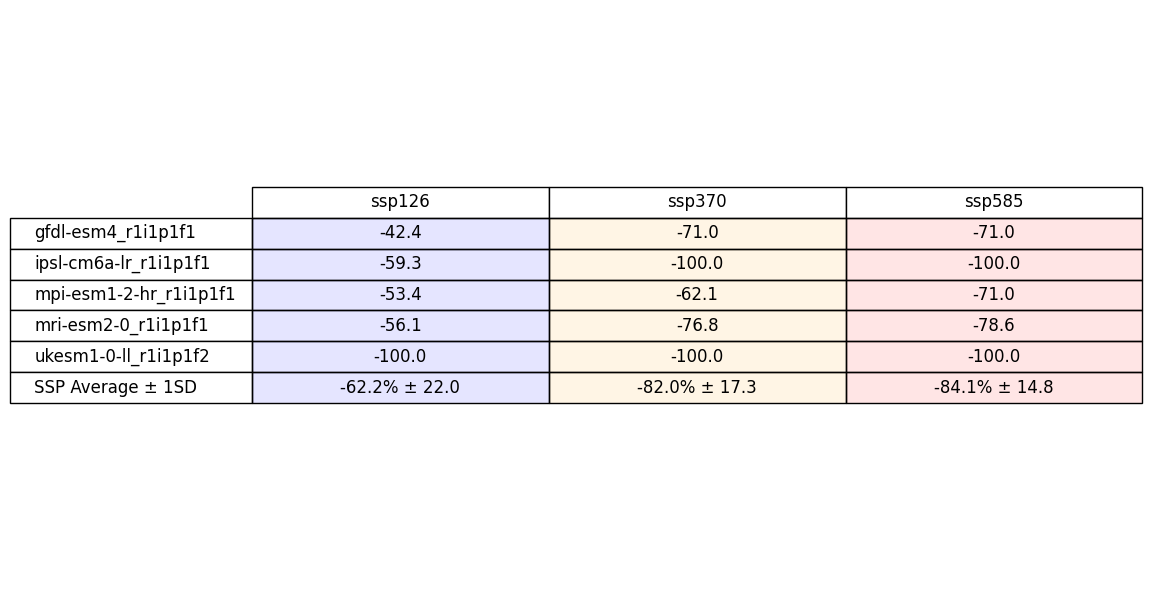

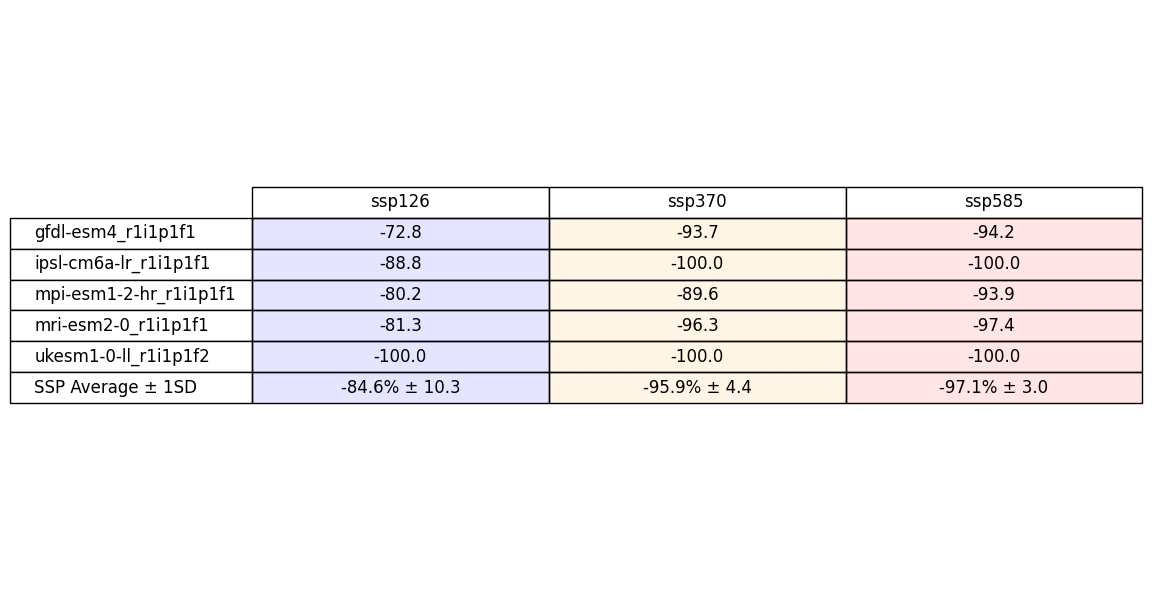

In [4]:
# Extract values for 2100 for each GCM and SSP combination
gcm_ssp_results = []

# First get the 2000 reference values from the historical run
ds_hist = utils.compile_run_output(gdirs, input_filesuffix='_dynamic_spinup')
volume_2000 = ds_hist.volume.sum(dim='rgi_id').isel(time=0).values
area_2000 = ds_hist.area.sum(dim='rgi_id').isel(time=0).values

for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        ds_proj = utils.compile_run_output(gdirs, input_filesuffix=rid)
        
        # Calculate volume at 2100
        volume_2100 = ds_proj.volume.sel(time='2100', method='nearest').sum(dim='rgi_id')
        
        # Calculate percentage of volume loss relative to 2000 (negative value)
        volume_loss_percentage = -((volume_2000 - volume_2100) / volume_2000 * 100)
        
        # Calculate area at 2100
        area_2100 = ds_proj.area.sel(time='2100', method='nearest').sum(dim='rgi_id')
        
        # Calculate percentage of area loss relative to 2000 (negative value)
        area_loss_percentage = -((area_2000 - area_2100) / area_2000 * 100)
        
        # Append results
        gcm_ssp_results.append({
            'GCM': gcm,
            'Scenario': ssp,
            'Volume 2100 (m³)': round(float(volume_2100.values), 2),  # Volume at 2100
            'Volume Relative to 2000 (%)': round(float(volume_loss_percentage), 1),  # % of volume loss (negative)
            'Area 2100 (km²)': round(float(area_2100.values), 2)* 1e-6,  # Area at 2100
            'Area Relative to 2000 (%)': round(float(area_loss_percentage), 1)  # % of area loss (negative)
        })

# Create a DataFrame from the results
df_gcm_ssp = pd.DataFrame(gcm_ssp_results)

# Pivot the DataFrame for area and volume loss  
area_loss_table = df_gcm_ssp.pivot(index='GCM', columns='Scenario', values='Area Relative to 2000 (%)')  
volume_loss_table = df_gcm_ssp.pivot(index='GCM', columns='Scenario', values='Volume Relative to 2000 (%)')  

# Calculate the average and standard deviation for each SSP (across GCMs)  
ssp_averages_area = area_loss_table.mean().round(1)  
ssp_std_area = area_loss_table.std().round(1)  
ssp_averages_volume = volume_loss_table.mean().round(1)  
ssp_std_volume = volume_loss_table.std().round(1)  

# Combine average and standard deviation into a single string   
area_loss_table.loc['SSP Average ± 1SD'] = ssp_averages_area.astype(str) + "% ± " + ssp_std_area.astype(str)  
volume_loss_table.loc['SSP Average ± 1SD'] = ssp_averages_volume.astype(str) + "% ± " + ssp_std_volume.astype(str)  

# Add a title for the GCM column  
area_loss_table.index.name = 'GCM'  
volume_loss_table.index.name = 'GCM'  

# Define the color dictionary for scenarios  
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}  

# Function to plot and save a table  
def plot_tables(data, filename):  
    # Create a color map for the table with alpha  
    cell_colors = []  
    for idx, row in data.iterrows():  
        row_colors = []  
        for col in data.columns:  
            # Apply alpha to scenario colors (same for all rows, including SSP Average)  
            row_colors.append(to_rgba(color_dict[col], alpha=0.1))  
        cell_colors.append(row_colors)  

    # Plot the table  
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjust the size as needed  
    ax.axis('tight')  
    ax.axis('off')  
    table = ax.table(  
        cellText=data.values,  
        rowLabels=data.index,  
        colLabels=data.columns,  
        loc='center',  
        cellLoc='center',  
        cellColours=cell_colors  
    )  

    # Adjust table style  
    table.auto_set_font_size(False)  
    table.set_fontsize(12)  
    table.scale(1.2, 1.5)  
    plt.tight_layout()  
    
    # Save the figure  
    plt.savefig(filename, dpi=300, bbox_inches='tight')  
    
    plt.show()  

# Plot and save the tables  
plot_tables(area_loss_table, "figureout/area_loss.png")  
plot_tables(volume_loss_table, "figureout/volume_loss.png")  

# Save the area and volume loss tables as CSV  
area_loss_table.to_csv("tableout/area_loss.csv")  
volume_loss_table.to_csv("tableout/volume_loss.csv")
